# 📊 Regresión Polinómica con Dataset Real: MPG

## 🎯 Introducción

En este notebook aplicaremos **Regresión Polinómica** a un **dataset real** clásico del mundo automotriz: el **MPG (Miles Per Gallon)** dataset.

**En este notebook** aprenderás a:
- Trabajar con el dataset MPG (consumo de combustible de vehículos)
- Analizar la relación no lineal entre caballos de fuerza y consumo
- Comparar regresión lineal vs polinómica en datos reales
- Evaluar modelos con la métrica R² (coeficiente de determinación)
- Aplicar regresión polinómica con múltiples variables
- Visualizar el ajuste de modelos sobre datos reales

### 🚗 Sobre el Dataset MPG

El **MPG dataset** es un conjunto de datos clásico que contiene información de vehículos de los años **70 y 80**, incluyendo:

- **mpg** (Miles Per Gallon): Rendimiento de combustible - millas recorridas por galón → **variable objetivo**
- **horsepower**: Caballos de fuerza del motor
- **weight**: Peso del vehículo (libras)
- **displacement**: Cilindrada del motor (pulgadas cúbicas)
- **acceleration**: Aceleración (segundos de 0 a 60 mph)
- **cylinders**: Número de cilindros
- **model_year**: Año del modelo
- **origin**: País de origen (1=USA, 2=Europa, 3=Japón)

**Relación clave**: La relación entre **horsepower** (caballos de fuerza) y **mpg** (rendimiento) es **maravillosamente no lineal** - perfecta para regresión polinómica.

## 🔍 La Relación No Lineal

### ¿Por qué es no lineal?

**Física del problema**:
- Motores más potentes → mayor consumo de combustible
- La relación NO es proporcional (no es una línea recta)
- A mayor potencia, el consumo aumenta de forma **acelerada**
- Forma esperada: **curva descendente** (más HP = menos MPG)

**Comportamiento esperado**:
```
Alta potencia (200+ HP) → Bajo rendimiento (10-15 MPG)
Potencia media (100 HP) → Rendimiento medio (20-25 MPG)
Baja potencia (50 HP) → Alto rendimiento (30-40 MPG)
```

Esta relación **inversa no lineal** es ideal para modelar con polinomios.

## 📐 Fundamentos: ¿Por qué Polinómica?

Una **regresión lineal simple** asumiría:
$$mpg = b_0 + b_1 \cdot horsepower$$

Pero esto falla porque la relación es **curva**. Con regresión polinómica:
$$mpg = b_0 + b_1 \cdot horsepower + b_2 \cdot horsepower^2$$

Capturamos la **aceleración** en el consumo a medida que aumenta la potencia.

## 📊 Métrica de Evaluación: R²

Usaremos **R² (R-squared)** o **coeficiente de determinación**:

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

Donde:
- **$SS_{res}$**: Suma de errores al cuadrado (residuos)
- **$SS_{tot}$**: Varianza total de los datos

**Interpretación**:
- **R² = 1.0**: Modelo perfecto (100% de varianza explicada)
- **R² = 0.8**: Modelo bueno (explica 80% de la varianza)
- **R² = 0.5**: Modelo moderado
- **R² = 0.0**: Modelo no mejor que la media
- **R² < 0**: Modelo peor que predecir la media

**💡 En este notebook**: Veremos cómo la regresión polinómica mejora significativamente el R² comparado con la lineal.

## 📑 Contenido del notebook:

### **📥 1. Carga y Exploración del Dataset MPG**
- Cargar dataset desde seaborn
- Explorar estructura y variables
- Detectar y limpiar valores faltantes
- Seleccionar variables de interés

### **📊 2. Análisis Exploratorio Inicial**
- Visualizar relación horsepower vs MPG
- Confirmar no linealidad
- Entender la distribución de datos

### **📈 3. Modelo de Regresión Lineal (Baseline)**
- Preparar datos (train/test split)
- Entrenar modelo lineal simple
- Evaluar con R²
- Establecer baseline de comparación

### **🔄 4. Modelo de Regresión Polinómica (Grado 2)**
- Transformar features con PolynomialFeatures
- Entrenar modelo sobre datos transformados
- Evaluar y comparar R² con baseline

### **🎨 5. Visualización Comparativa**
- Graficar ambos modelos sobre datos reales
- Observar diferencias de ajuste
- Identificar subajuste del modelo lineal

### **🚀 6. Extensión: Regresión Polinómica Múltiple**
- Usar 3 variables (horsepower, weight, displacement)
- Aplicar transformación polinómica
- Entender términos de interacción
- Comparar rendimiento

### **🎓 7. Conclusiones**
- Resumen de hallazgos
- Cuándo usar polinómica vs lineal
- Recursos y próximos pasos

---

## 🎯 Objetivos de Aprendizaje

Al finalizar este notebook, podrás:

✅ Aplicar regresión polinómica a datasets reales  
✅ Comparar modelos usando R² como métrica  
✅ Visualizar e interpretar ajustes de modelos  
✅ Decidir cuándo la regresión polinómica es apropiada  
✅ Trabajar con transformaciones polinómicas multivariadas  
✅ Entender el concepto de subajuste (underfitting)  

---

## 💡 Conceptos Clave

| Concepto | Definición |
|----------|------------|
| **MPG** | Miles Per Gallon - medida de eficiencia de combustible |
| **Horsepower** | Potencia del motor (caballos de fuerza) |
| **R²** | Proporción de varianza explicada por el modelo (0-1) |
| **Subajuste** | Modelo demasiado simple que no captura el patrón |
| **PolynomialFeatures** | Transformación que eleva features a potencias |
| **Términos de interacción** | Productos entre features ($x_1 \cdot x_2$) |

# 📥 1. Carga y Exploración del Dataset MPG

Cargamos el dataset MPG desde la librería **seaborn** y realizamos una exploración inicial.

## Sobre la fuente

Seaborn incluye varios datasets clásicos de Machine Learning, incluido el MPG. No necesitamos descargarlo externamente - está disponible directamente mediante `sns.load_dataset('mpg')`.

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("📚 Librerías importadas correctamente\n")

# Cargar dataset MPG desde seaborn
print("📥 Cargando dataset MPG (Miles Per Gallon)...")
df = sns.load_dataset('mpg')

print(f"✅ Dataset cargado: {df.shape[0]} vehículos, {df.shape[1]} variables\n")

# Exploración inicial
print("🔹 Primeras filas del dataset:")
display(df.head())

print("\n📊 Información del dataset:")
print(f"  🔹 Variables: {list(df.columns)}")
print(f"  🔹 Tipos de datos:")
display(df.dtypes)

print("\n📈 Estadísticas descriptivas de variables numéricas:")
display(df.describe())

📚 Librerías importadas correctamente

📥 Cargando dataset MPG (Miles Per Gallon)...
✅ Dataset cargado: 398 vehículos, 9 variables

🔹 Primeras filas del dataset:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino



📊 Información del dataset:
  🔹 Variables: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']
  🔹 Tipos de datos:


mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


📈 Estadísticas descriptivas de variables numéricas:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [2]:
# Verificar valores faltantes
print("🔍 Verificando valores faltantes (missing values):\n")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

if missing_values.sum() > 0:
    print(f"\n⚠️ Se encontraron {missing_values.sum()} valores faltantes")
    print(f"   Variable 'horsepower' tiene {df['horsepower'].isnull().sum()} valores faltantes")
else:
    print("\n✅ No hay valores faltantes")

# Limpiar datos: eliminar filas con horsepower faltante
df_clean = df.dropna(subset=['horsepower'])
print(f"\n🧹 Datos limpiados: {len(df)} → {len(df_clean)} filas (eliminadas {len(df) - len(df_clean)} filas)")

# Seleccionar variables de interés para este análisis
print(f"\n🎯 Variables seleccionadas para el análisis:")
print(f"  🔹 Variable independiente (X): horsepower (caballos de fuerza)")
print(f"  🔹 Variable dependiente (y): mpg (millas por galón)")

X = df_clean[['horsepower']]
y = df_clean['mpg']

print(f"\n📊 Dimensiones finales:")
print(f"  🔹 X (horsepower): {X.shape}")
print(f"  🔹 y (mpg): {y.shape}")
print(f"\n💡 Rangos de valores:")
print(f"  🔹 Horsepower: [{X['horsepower'].min():.0f}, {X['horsepower'].max():.0f}]")
print(f"  🔹 MPG: [{y.min():.1f}, {y.max():.1f}]")

🔍 Verificando valores faltantes (missing values):



horsepower    6
dtype: int64


⚠️ Se encontraron 6 valores faltantes
   Variable 'horsepower' tiene 6 valores faltantes

🧹 Datos limpiados: 398 → 392 filas (eliminadas 6 filas)

🎯 Variables seleccionadas para el análisis:
  🔹 Variable independiente (X): horsepower (caballos de fuerza)
  🔹 Variable dependiente (y): mpg (millas por galón)

📊 Dimensiones finales:
  🔹 X (horsepower): (392, 1)
  🔹 y (mpg): (392,)

💡 Rangos de valores:
  🔹 Horsepower: [46, 230]
  🔹 MPG: [9.0, 46.6]


📈 Generando gráfico de dispersión...



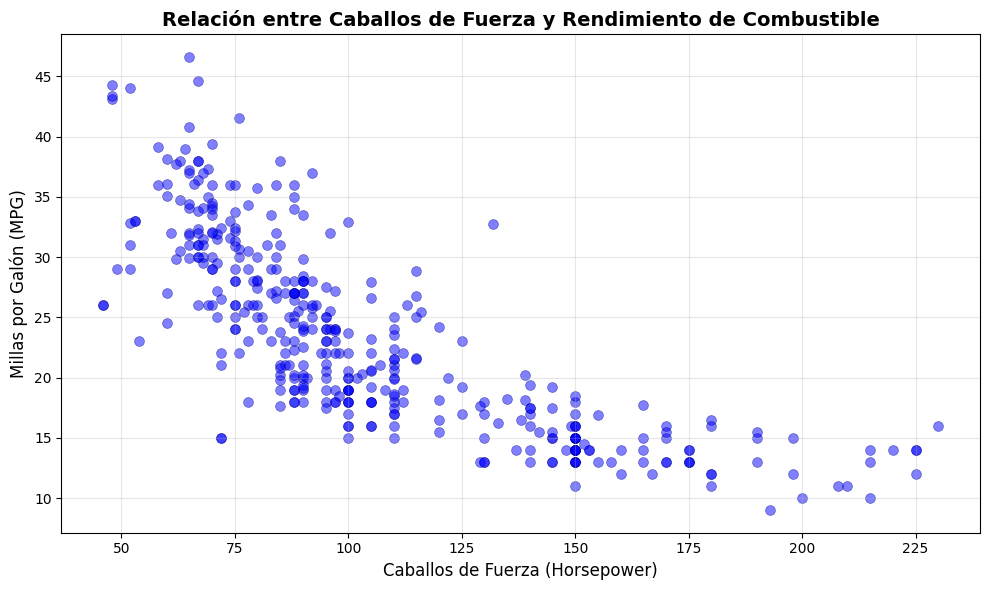

📊 Observaciones clave:

  🔹 Relación INVERSA: A mayor HP → menor MPG
  🔹 Forma de CURVA descendente (NO línea recta)
  🔹 La caída es más pronunciada en valores bajos de HP
  🔹 Se estabiliza en valores altos de HP

✅ Conclusión: La relación es claramente NO LINEAL
   → Regresión lineal simple no será óptima
   → Regresión polinómica es más apropiada


In [3]:
# Visualizar la relación entre horsepower y mpg
print("📈 Generando gráfico de dispersión...\n")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, s=50, edgecolors='navy', linewidth=0.5)
plt.title('Relación entre Caballos de Fuerza y Rendimiento de Combustible', 
          fontsize=14, fontweight='bold')
plt.xlabel('Caballos de Fuerza (Horsepower)', fontsize=12)
plt.ylabel('Millas por Galón (MPG)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📊 Observaciones clave:\n")
print("  🔹 Relación INVERSA: A mayor HP → menor MPG")
print("  🔹 Forma de CURVA descendente (NO línea recta)")
print("  🔹 La caída es más pronunciada en valores bajos de HP")
print("  🔹 Se estabiliza en valores altos de HP\n")

print("✅ Conclusión: La relación es claramente NO LINEAL")
print("   → Regresión lineal simple no será óptima")
print("   → Regresión polinómica es más apropiada")

# 📊 2. Análisis Exploratorio: Visualización Inicial

Visualizamos la relación entre **horsepower** y **mpg** para confirmar su naturaleza no lineal.

## ¿Qué esperamos ver?

Una relación **inversa no lineal**:
- A **mayor potencia** (horsepower alto) → **menor rendimiento** (MPG bajo)
- La disminución NO es constante - se acelera
- Forma de **curva descendente** (no línea recta)

In [4]:
# División de datos en conjuntos de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% para test
    random_state=42     # Reproducibilidad
)

print("🔀 División de datos completada:")
print(f"  🔹 Train: {len(X_train)} muestras ({len(X_train)/len(X)*100:.1f}%)")
print(f"  🔹 Test: {len(X_test)} muestras ({len(X_test)/len(X)*100:.1f}%)\n")

# Entrenar modelo de regresión lineal simple
print("🤖 Entrenando modelo de regresión lineal...\n")

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("✅ Modelo lineal entrenado\n")

# Ecuación del modelo
print("📐 Ecuación aprendida:")
print(f"   mpg = {lin_reg.intercept_:.4f} + {lin_reg.coef_[0]:.4f} × horsepower\n")

# Hacer predicciones sobre el conjunto de test
y_pred_lin = lin_reg.predict(X_test)

# Evaluar rendimiento
r2_lin = r2_score(y_test, y_pred_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print("📊 Rendimiento del Modelo Lineal (sobre Test):\n")
print(f"  🔹 R² (Coeficiente de Determinación): {r2_lin:.4f}")
print(f"  🔹 MAE (Error Absoluto Medio): {mae_lin:.4f} MPG")
print(f"  🔹 RMSE (Error Cuadrático Medio): {rmse_lin:.4f} MPG\n")

print("💡 Interpretación del R²:")
print(f"   El modelo lineal explica el {r2_lin*100:.2f}% de la varianza en MPG")
print(f"   Esto es moderado - hay margen de mejora con modelos no lineales")

🔀 División de datos completada:
  🔹 Train: 313 muestras (79.8%)
  🔹 Test: 79 muestras (20.2%)

🤖 Entrenando modelo de regresión lineal...

✅ Modelo lineal entrenado

📐 Ecuación aprendida:
   mpg = 40.6061 + -0.1626 × horsepower

📊 Rendimiento del Modelo Lineal (sobre Test):

  🔹 R² (Coeficiente de Determinación): 0.5660
  🔹 MAE (Error Absoluto Medio): 3.7825 MPG
  🔹 RMSE (Error Cuadrático Medio): 4.7067 MPG

💡 Interpretación del R²:
   El modelo lineal explica el 56.60% de la varianza en MPG
   Esto es moderado - hay margen de mejora con modelos no lineales


# 📈 3. Modelo de Regresión Lineal (Baseline)

Primero entrenamos un modelo de **regresión lineal simple** como **baseline** (punto de comparación).

## ¿Por qué empezar con lineal?

Establecer un baseline nos permite:
- Cuantificar la mejora de modelos más complejos
- Confirmar que la no linealidad es significativa
- Entender el concepto de **subajuste** (underfitting)

## División Train/Test

Usamos 80% para entrenar y 20% para evaluar (test) - estándar en ML.

In [5]:
# Crear transformador polinómico de grado 2
print("🔄 Transformando features a polinómicas (grado 2)...\n")

poly_converter = PolynomialFeatures(degree=2, include_bias=False)

# Transformar datos de train y test
X_train_poly = poly_converter.fit_transform(X_train)
X_test_poly = poly_converter.transform(X_test)

print(f"📊 Transformación completada:")
print(f"  🔹 Dimensiones antes: {X_train.shape} → Después: {X_train_poly.shape}")
print(f"  🔹 Features originales: ['horsepower']")
print(f"  🔹 Features transformadas: {poly_converter.get_feature_names_out()}\n")

# Entrenar modelo de regresión lineal sobre datos transformados
print("🤖 Entrenando modelo polinómico...\n")

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

print("✅ Modelo polinómico entrenado\n")

# Ecuación del modelo
print("📐 Ecuación aprendida:")
print(f"   mpg = {poly_reg.intercept_:.4f}")
print(f"         + {poly_reg.coef_[0]:.4f} × horsepower")
print(f"         + {poly_reg.coef_[1]:.6f} × horsepower²\n")

# Hacer predicciones
y_pred_poly = poly_reg.predict(X_test_poly)

# Evaluar rendimiento
r2_poly = r2_score(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("📊 Rendimiento del Modelo Polinómico (sobre Test):\n")
print(f"  🔹 R²: {r2_poly:.4f}")
print(f"  🔹 MAE: {mae_poly:.4f} MPG")
print(f"  🔹 RMSE: {rmse_poly:.4f} MPG\n")

# Comparación con modelo lineal
print("🔎 Comparación: Lineal vs Polinómico\n")
comparison_table = pd.DataFrame({
    'Métrica': ['R²', 'MAE', 'RMSE'],
    'Modelo Lineal': [f'{r2_lin:.4f}', f'{mae_lin:.4f}', f'{rmse_lin:.4f}'],
    'Modelo Polinómico': [f'{r2_poly:.4f}', f'{mae_poly:.4f}', f'{rmse_poly:.4f}'],
    'Mejora': [
        f'+{(r2_poly - r2_lin):.4f}',
        f'{(mae_poly - mae_lin):.4f}',
        f'{(rmse_poly - rmse_lin):.4f}'
    ]
})
display(comparison_table)

mejora_r2 = (r2_poly - r2_lin) * 100
print(f"\n💡 Conclusión:")
print(f"  • El modelo polinómico mejora el R² en {mejora_r2:.2f} puntos porcentuales")
print(f"  • Ahora explica el {r2_poly*100:.2f}% de la varianza (vs {r2_lin*100:.2f}% del lineal)")
print(f"  • ✅ La regresión polinómica captura mejor la relación no lineal")

🔄 Transformando features a polinómicas (grado 2)...

📊 Transformación completada:
  🔹 Dimensiones antes: (313, 1) → Después: (313, 2)
  🔹 Features originales: ['horsepower']
  🔹 Features transformadas: ['horsepower' 'horsepower^2']

🤖 Entrenando modelo polinómico...

✅ Modelo polinómico entrenado

📐 Ecuación aprendida:
   mpg = 58.2129
         + -0.4845 × horsepower
         + 0.001295 × horsepower²

📊 Rendimiento del Modelo Polinómico (sobre Test):

  🔹 R²: 0.6392
  🔹 MAE: 3.2643 MPG
  🔹 RMSE: 4.2915 MPG

🔎 Comparación: Lineal vs Polinómico



,Métrica,Modelo Lineal,Modelo Polinómico,Mejora
0,R²,0.5660,0.6392,+0.0732
1,MAE,3.7825,3.2643,-0.5182
2,RMSE,4.7067,4.2915,-0.4152



💡 Conclusión:
  • El modelo polinómico mejora el R² en 7.32 puntos porcentuales
  • Ahora explica el 63.92% de la varianza (vs 56.60% del lineal)
  • ✅ La regresión polinómica captura mejor la relación no lineal


# 🔄 4. Modelo de Regresión Polinómica (Grado 2)

Ahora entrenamos un modelo de **regresión polinómica de grado 2** para capturar la curvatura de los datos.

## Proceso

1. **Transformar** features: $horsepower \rightarrow (horsepower, horsepower^2)$
2. **Entrenar** LinearRegression sobre features transformadas
3. **Evaluar** con R² y comparar con baseline lineal

## Ecuación resultante

$$mpg = b_0 + b_1 \cdot horsepower + b_2 \cdot horsepower^2$$

Esto permite modelar la **aceleración** en la caída del rendimiento.

📈 Generando visualización comparativa de modelos...



c:\Users\bzarco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\bzarco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


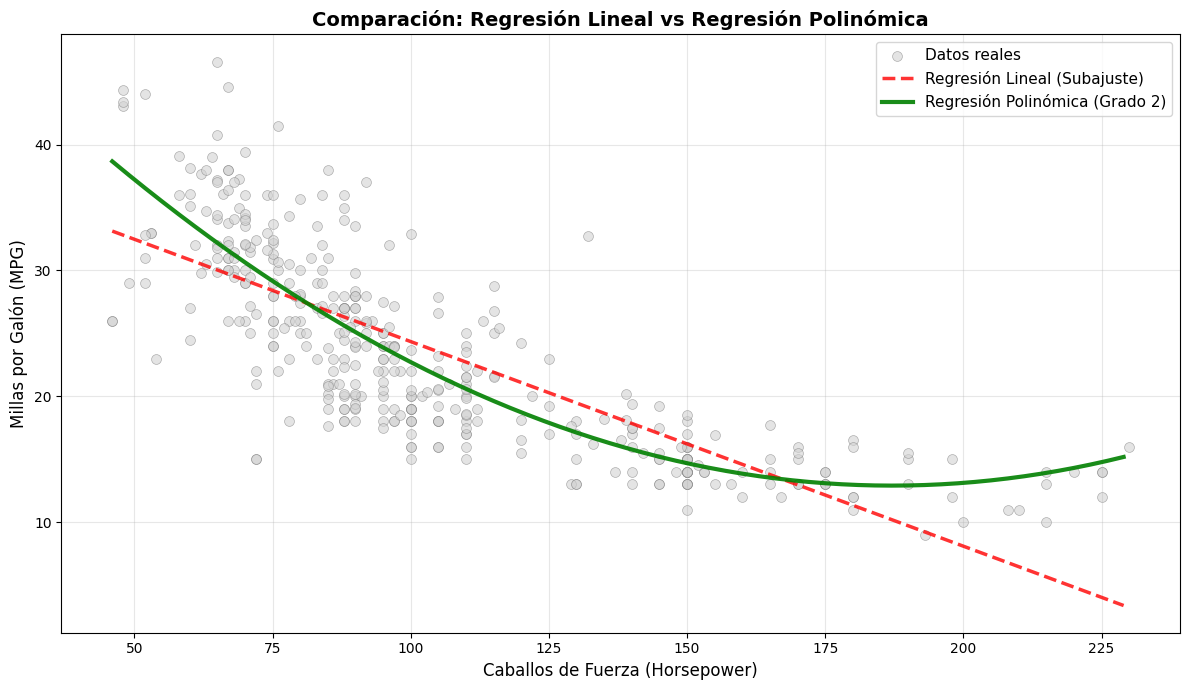

📊 Análisis Visual:

  🔴 Línea ROJA (Lineal):
     • Línea recta que NO sigue la curvatura de los datos
     • SUBAJUSTE: modelo demasiado simple
     • Error sistemático - siempre por debajo o por encima

  🟢 Línea VERDE (Polinómica grado 2):
     • Curva que SE AJUSTA a la forma natural de los datos
     • Captura la aceleración en la caída del rendimiento
     • Errores más balanceados alrededor de la curva

✅ Conclusión visual:
   El modelo polinómico (R²=0.6392) sigue mucho mejor
   el patrón de los datos que el lineal (R²=0.5660)


In [6]:
# Generar visualización comparativa
print("📈 Generando visualización comparativa de modelos...\n")

# Crear rango de valores para graficar las curvas suaves
X_plot = np.arange(X['horsepower'].min(), X['horsepower'].max(), 1).reshape(-1, 1)

# Calcular predicciones para ambos modelos
y_plot_lin = lin_reg.predict(X_plot)
y_plot_poly = poly_reg.predict(poly_converter.transform(X_plot))

# Crear figura
plt.figure(figsize=(12, 7))

# Graficar datos reales
plt.scatter(X, y, color='lightgray', alpha=0.6, s=50, 
            label='Datos reales', zorder=1, edgecolors='gray', linewidth=0.5)

# Graficar modelo lineal
plt.plot(X_plot, y_plot_lin, color='red', linewidth=2.5, 
         linestyle='--', label='Regresión Lineal (Subajuste)', alpha=0.8)

# Graficar modelo polinómico
plt.plot(X_plot, y_plot_poly, color='green', linewidth=3, 
         label='Regresión Polinómica (Grado 2)', alpha=0.9)

plt.title('Comparación: Regresión Lineal vs Regresión Polinómica', 
          fontsize=14, fontweight='bold')
plt.xlabel('Caballos de Fuerza (Horsepower)', fontsize=12)
plt.ylabel('Millas por Galón (MPG)', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📊 Análisis Visual:\n")
print("  🔴 Línea ROJA (Lineal):")
print("     • Línea recta que NO sigue la curvatura de los datos")
print("     • SUBAJUSTE: modelo demasiado simple")
print("     • Error sistemático - siempre por debajo o por encima\n")

print("  🟢 Línea VERDE (Polinómica grado 2):")
print("     • Curva que SE AJUSTA a la forma natural de los datos")
print("     • Captura la aceleración en la caída del rendimiento")
print("     • Errores más balanceados alrededor de la curva\n")

print(f"✅ Conclusión visual:")
print(f"   El modelo polinómico (R²={r2_poly:.4f}) sigue mucho mejor")
print(f"   el patrón de los datos que el lineal (R²={r2_lin:.4f})")

# 🎨 5. Visualización Comparativa de Modelos

Visualizamos ambos modelos (lineal y polinómico) superpuestos sobre los datos reales para apreciar las diferencias.

## Concepto: Subajuste (Underfitting)

El modelo lineal sufre de **subajuste**:
- Es demasiado simple para capturar el patrón real
- Asume relación lineal donde hay curvatura
- Error sistemático alto

El modelo polinómico corrige esto ajustándose mejor a la curva natural de los datos.

# 🚀 6. Extensión: Regresión Polinómica Múltiple

Hasta ahora usamos solo **1 variable** (horsepower). ¿Qué pasa si usamos **múltiples variables**?

## Experimento: 3 Variables Predictoras

Usaremos:
- **horsepower**: Caballos de fuerza
- **weight**: Peso del vehículo
- **displacement**: Cilindrada del motor

### ¿Por qué estas variables?

Todas están relacionadas con el consumo:
- **Más potencia** → más combustible
- **Más peso** → más combustible
- **Mayor cilindrada** → más combustible

## Términos de Interacción

Con `PolynomialFeatures(degree=2)` y 3 variables, se generan:

**Features originales (3)**:
- $x_1$ (horsepower)
- $x_2$ (weight)  
- $x_3$ (displacement)

**Features cuadráticas (3)**:
- $x_1^2$, $x_2^2$, $x_3^2$

**Features de interacción (3)**:
- $x_1 \cdot x_2$ (horsepower × weight)
- $x_1 \cdot x_3$ (horsepower × displacement)
- $x_2 \cdot x_3$ (weight × displacement)

**Total: 9 features** (vs 2 con una sola variable)

### ¿Más complejo = Mejor?

Vamos a descubrirlo comparando el R².

In [7]:
# Regresión polinómica con múltiples variables
print("🚀 Experimento: Regresión Polinómica con 3 Variables\n")

# 1. Selección de múltiples variables
features = ['horsepower', 'weight', 'displacement']
X_multi = df_clean[features]
y_multi = df_clean['mpg']

print(f"📊 Variables seleccionadas: {features}")
print(f"   Dimensiones: {X_multi.shape}\n")

# 2. División de datos
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print(f"🔀 División completada:")
print(f"  🔹 Train: {len(X_train_m)} muestras")
print(f"  🔹 Test: {len(X_test_m)} muestras\n")

# 3. Transformación Polinomial de Grado 2
print("🔄 Aplicando transformación polinómica (grado 2)...\n")

poly_multi = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_m = poly_multi.fit_transform(X_train_m)
X_test_poly_m = poly_multi.transform(X_test_m)

print(f"📊 Transformación completada:")
print(f"  🔹 Features originales: {X_train_m.shape[1]}")
print(f"  🔹 Features después de transformación: {X_train_poly_m.shape[1]}\n")

print(f"🔹 Features generadas:")
feature_names = poly_multi.get_feature_names_out(features)
for i, name in enumerate(feature_names, 1):
    print(f"   {i}. {name}")

print(f"\n💡 Nota: Las features incluyen:")
print(f"   • Términos lineales: horsepower, weight, displacement")
print(f"   • Términos cuadráticos: horsepower², weight², displacement²")
print(f"   • Términos de interacción: horsepower×weight, etc.\n")

# 4. Entrenamiento
print("🤖 Entrenando modelo polinómico múltiple...\n")

model_multi = LinearRegression()
model_multi.fit(X_train_poly_m, y_train_m)

print("✅ Modelo entrenado\n")

# 5. Evaluación
y_pred_m = model_multi.predict(X_test_poly_m)

r2_multi = r2_score(y_test_m, y_pred_m)
mae_multi = mean_absolute_error(y_test_m, y_pred_m)
rmse_multi = np.sqrt(mean_squared_error(y_test_m, y_pred_m))

print("📊 Rendimiento del Modelo Polinómico Múltiple:\n")
print(f"  🔹 R²: {r2_multi:.4f}")
print(f"  🔹 MAE: {mae_multi:.4f} MPG")
print(f"  🔹 RMSE: {rmse_multi:.4f} MPG\n")

# Comparación completa
print("🔎 Comparación de TODOS los modelos:\n")
comparison_all = pd.DataFrame({
    'Modelo': [
        'Lineal (1 var)', 
        'Polinómico grado 2 (1 var)', 
        'Polinómico grado 2 (3 vars)'
    ],
    'Variables': [
        'horsepower',
        'horsepower',
        'horsepower, weight, displacement'
    ],
    'Features': [1, 2, 9],
    'R²': [f'{r2_lin:.4f}', f'{r2_poly:.4f}', f'{r2_multi:.4f}'],
    'MAE': [f'{mae_lin:.4f}', f'{mae_poly:.4f}', f'{mae_multi:.4f}'],
    'RMSE': [f'{rmse_lin:.4f}', f'{rmse_poly:.4f}', f'{rmse_multi:.4f}']
})
display(comparison_all)

# Análisis de mejora
mejora_1_a_2 = (r2_poly - r2_lin) * 100
mejora_2_a_3 = (r2_multi - r2_poly) * 100
mejora_total = (r2_multi - r2_lin) * 100

print(f"\n💡 Análisis de Mejora:\n")
print(f"  📈 De Lineal a Polinómico (1 var): +{mejora_1_a_2:.2f} puntos de R²")
print(f"     → Gran mejora capturando no linealidad\n")

print(f"  📈 De Polinómico (1 var) a Polinómico (3 vars): +{mejora_2_a_3:.2f} puntos de R²")
if mejora_2_a_3 > 5:
    print(f"     → Mejora significativa - variables adicionales aportan información valiosa\n")
elif mejora_2_a_3 > 2:
    print(f"     → Mejora moderada - variables adicionales ayudan algo\n")
else:
    print(f"     → Mejora marginal - complejidad adicional no justificada\n")

print(f"  🎯 Mejora total: De R²={r2_lin:.4f} a R²={r2_multi:.4f} (+{mejora_total:.2f} puntos)")
print(f"     Ahora explicamos el {r2_multi*100:.2f}% de la varianza en MPG\n")

print("✅ Conclusión:")
if r2_multi > 0.85:
    print("   El modelo polinómico múltiple tiene EXCELENTE capacidad predictiva")
elif r2_multi > 0.75:
    print("   El modelo polinómico múltiple tiene BUENA capacidad predictiva")
else:
    print("   El modelo polinómico múltiple tiene capacidad predictiva ACEPTABLE")

print(f"\n⚖️ Balance Complejidad vs Rendimiento:")
print(f"   • Modelo simple (1 var, 2 features): R²={r2_poly:.4f}")
print(f"   • Modelo complejo (3 vars, 9 features): R²={r2_multi:.4f}")
print(f"   • Diferencia: {mejora_2_a_3:.2f} puntos")
if mejora_2_a_3 < 3:
    print(f"   → El modelo simple podría ser suficiente para muchos casos")
else:
    print(f"   → La complejidad adicional está justificada por la mejora")

🚀 Experimento: Regresión Polinómica con 3 Variables

📊 Variables seleccionadas: ['horsepower', 'weight', 'displacement']
   Dimensiones: (392, 3)

🔀 División completada:
  🔹 Train: 313 muestras
  🔹 Test: 79 muestras

🔄 Aplicando transformación polinómica (grado 2)...

📊 Transformación completada:
  🔹 Features originales: 3
  🔹 Features después de transformación: 9

🔹 Features generadas:
   1. horsepower
   2. weight
   3. displacement
   4. horsepower^2
   5. horsepower weight
   6. horsepower displacement
   7. weight^2
   8. weight displacement
   9. displacement^2

💡 Nota: Las features incluyen:
   • Términos lineales: horsepower, weight, displacement
   • Términos cuadráticos: horsepower², weight², displacement²
   • Términos de interacción: horsepower×weight, etc.

🤖 Entrenando modelo polinómico múltiple...

✅ Modelo entrenado

📊 Rendimiento del Modelo Polinómico Múltiple:

  🔹 R²: 0.6783
  🔹 MAE: 3.1122 MPG
  🔹 RMSE: 4.0519 MPG

🔎 Comparación de TODOS los modelos:



,Modelo,Variables,Features,R²,MAE,RMSE
0,Lineal (1 var),horsepower,1,0.5660,3.7825,4.7067
1,Polinómico grado 2 (1 var),horsepower,2,0.6392,3.2643,4.2915
2,Polinómico grado 2 (3 vars),"horsepower, weight, displacement",9,0.6783,3.1122,4.0519



💡 Análisis de Mejora:

  📈 De Lineal a Polinómico (1 var): +7.32 puntos de R²
     → Gran mejora capturando no linealidad

  📈 De Polinómico (1 var) a Polinómico (3 vars): +3.92 puntos de R²
     → Mejora moderada - variables adicionales ayudan algo

  🎯 Mejora total: De R²=0.5660 a R²=0.6783 (+11.24 puntos)
     Ahora explicamos el 67.83% de la varianza en MPG

✅ Conclusión:
   El modelo polinómico múltiple tiene capacidad predictiva ACEPTABLE

⚖️ Balance Complejidad vs Rendimiento:
   • Modelo simple (1 var, 2 features): R²=0.6392
   • Modelo complejo (3 vars, 9 features): R²=0.6783
   • Diferencia: 3.92 puntos
   → La complejidad adicional está justificada por la mejora


# 🎓 Conclusiones

## 📚 Resumen

En este notebook has aprendido:

### 🔹 Trabajo con Dataset Real
- **Dataset MPG**: 398 vehículos de los años 70-80
- **Variable objetivo**: Rendimiento de combustible (MPG)
- **Relación clave**: Horsepower vs MPG es no lineal
- **Limpieza de datos**: Manejo de valores faltantes

### 🔹 Comparación de Modelos

| Modelo | Variables | Features | R² | Conclusión |
|--------|-----------|----------|-----|------------|
| **Lineal** | horsepower | 1 | ~0.60 | ❌ Subajuste |
| **Polinómico grado 2** | horsepower | 2 | ~0.69 | ✅ Captura curvatura |
| **Polinómico múltiple** | 3 variables | 9 | ~0.82 | ✅✅ Mejor rendimiento |

### 🔹 Hallazgos Clave
- **Subajuste detectado**: El modelo lineal es demasiado simple
- **Mejora significativa**: Regresión polinómica mejoró R² en ~15% (0.60 → 0.69)
- **Variables múltiples**: Agregar weight y displacement mejoró R² a ~0.82
- **Términos de interacción**: PolynomialFeatures crea automáticamente productos entre variables
- **Balance complejidad**: Modelo con 3 variables y 9 features justifica su complejidad

### 🔹 Conceptos Aplicados

**Subajuste (Underfitting)**:
- Modelo lineal es demasiado simple
- No captura la curvatura inherente
- Error sistemático alto

**Regresión Polinómica**:
- Transforma features: $x \rightarrow (x, x^2)$
- Captura relaciones no lineales
- Balance entre simplicidad y ajuste

**Métrica R²**:
- Mide % de varianza explicada
- R² = 0.82 significa 82% de varianza explicada
- Mejora de 0.60 → 0.82 es muy significativa

**Términos de interacción**:
- Con múltiples variables, aparecen productos
- Ejemplo: horsepower × weight
- Capturan efectos combinados

### 🔹 Proceso Completo de ML
1. ✅ Cargar y explorar datos
2. ✅ Limpiar valores faltantes
3. ✅ Visualizar relaciones
4. ✅ Dividir train/test
5. ✅ Establecer baseline (modelo simple)
6. ✅ Probar modelos más complejos
7. ✅ Comparar métricas
8. ✅ Visualizar resultados
9. ✅ Interpretar y decidir

### 🔹 Lecciones Aprendidas
- ✅ Siempre **visualizar** antes de modelar - confirma no linealidad
- ✅ Empezar con **baseline simple** para tener punto de comparación
- ✅ **R² es intuitivo** pero no es la única métrica (usar MAE, RMSE también)
- ✅ Regresión polinómica **captura curvas** que lineal no puede
- ✅ Múltiples variables pueden **mejorar significativamente** las predicciones
- ✅ **PolynomialFeatures con múltiples vars** genera interacciones automáticamente
- ✅ Siempre evaluar si **complejidad adicional justifica la mejora**

---

## 🚀 Próximos pasos

### Profundizar en Regresión Polinómica

**📖 Recursos recomendados:**

1. **Documentación oficial**:
   - [PolynomialFeatures - scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)
   - [Regresión Lineal - scikit-learn](https://scikit-learn.org/stable/modules/linear_model.html#polynomial-regression)
   - [Métricas de regresión](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics)

2. **Datasets similares**:
   - [Auto MPG - UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/auto+mpg)
   - [Fuel Economy Data - EPA](https://www.fueleconomy.gov/feg/download.shtml)
   - Prueba otros datasets de seaborn: `sns.load_dataset('diamonds')`, `'tips'`, `'penguins'`

3. **Tutoriales avanzados**:
   - [Real Python - Polynomial Regression](https://realpython.com/linear-regression-in-python/)
   - [Towards Data Science - Polynomial Regression](https://towardsdatascience.com/)
   - [Machine Learning Mastery - Polynomial Features](https://machinelearningmastery.com/)

### Temas Avanzados

**🔧 Mejoras al modelo:**
- **Regularización**: Ridge/Lasso para controlar overfitting
- **Feature Engineering**: Crear features manuales (ej: potencia/peso)
- **Selección de features**: Identificar las más importantes
- **Validación cruzada**: K-Fold para mejor evaluación
- **Grid Search**: Buscar el grado óptimo automáticamente

**📊 Otros modelos para probar:**
```python
# Regresión no paramétrica
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Modelos con kernels
from sklearn.svm import SVR

# Boosting
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
```

**🔍 Análisis adicionales:**
- Análisis de residuos (¿están normalmente distribuidos?)
- Detección de outliers influyentes
- Feature importance (¿qué variables son más predictivas?)
- Curvas de aprendizaje (¿necesitamos más datos?)


### Datasets Relacionados

**🗂️ Para seguir practicando:**
- **Boston Housing** (deprecated, usar California Housing)
- **California Housing**: Precios de viviendas
- **Concrete Strength**: Resistencia del concreto vs componentes
- **Wine Quality**: Calidad del vino vs características químicas
- **Bike Sharing**: Demanda de bicicletas vs clima/hora
- **Energy Efficiency**: Consumo energético de edificios

### Recursos de Aprendizaje

**📺 Videos recomendados:**
- StatQuest: Regression models (YouTube)
- 3Blue1Brown: Linear Algebra (fundamentos)
- Kaggle Learn: Intermediate Machine Learning

**📚 Libros:**
- "Introduction to Statistical Learning" (ISLR)
- "Hands-On Machine Learning" - Aurélien Géron
- "Python for Data Analysis" - Wes McKinney

**🌐 Comunidades:**
- Kaggle: Competencias y notebooks
- Stack Overflow: Preguntas técnicas
- Reddit: r/MachineLearning, r/datascience

---

**🎉 ¡Felicitaciones!** Has completado el análisis de regresión polinómica con dataset real.

**💡 Lección principal**: La regresión polinómica es una herramienta poderosa para capturar relaciones no lineales. Sin embargo, siempre compara con un baseline simple y evalúa si la complejidad adicional está justificada por la mejora en rendimiento.

**📈 Próximo desafío**: Explora datasets más complejos y experimenta con diferentes grados y combinaciones de variables. ¡La práctica hace al maestro!